**Prática de Realce e detecção de borda**

Exercícios retirados de:
http://homepages.inf.ed.ac.uk/rbf/HIPR2/featops.htm



In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

1) Aplique os filtros  Sobel e Roberts nas imagens abaixo. Mostre, para o caso do Sobel, uma imagem representando a derivada em x e outra imagem representando a derivada em y

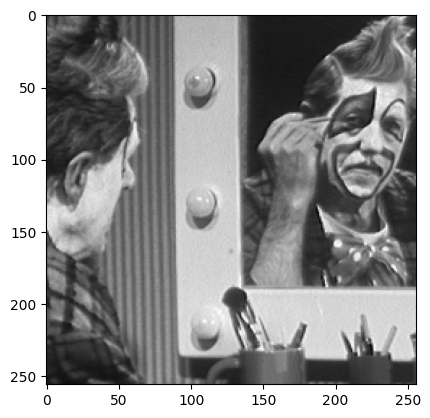

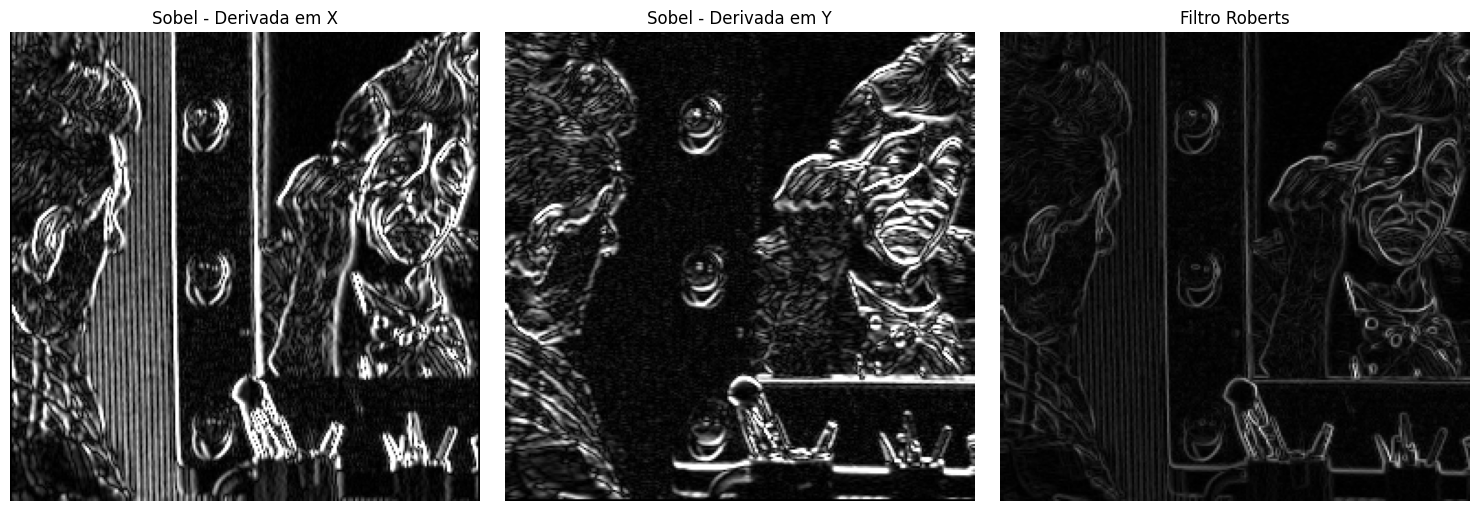

In [2]:

img1 = cv2.imread("cln1.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(img1, cmap='gray', vmin=0, vmax=255)

sobel_x = cv2.Sobel(img1, cv2.CV_64F, 1, 0, ksize=3)


sobel_y = cv2.Sobel(img1, cv2.CV_64F, 0, 1, ksize=3)


abs_sobel_x = cv2.convertScaleAbs(sobel_x)
abs_sobel_y = cv2.convertScaleAbs(sobel_y)

kernel_roberts_x = np.array([[1, 0], 
                             [0, -1]], dtype=np.float32)

kernel_roberts_y = np.array([[0, 1], 
                             [-1, 0]], dtype=np.float32)


roberts_x = cv2.filter2D(img1.astype(np.float32), -1, kernel_roberts_x)
roberts_y = cv2.filter2D(img1.astype(np.float32), -1, kernel_roberts_y)

roberts = cv2.magnitude(roberts_x, roberts_y)
roberts = cv2.convertScaleAbs(roberts)


plt.figure(figsize=(15, 5))


plt.subplot(1, 3, 1)
plt.imshow(abs_sobel_x, cmap='gray')
plt.title('Sobel - Derivada em X')
plt.axis('off')


plt.subplot(1, 3, 2)
plt.imshow(abs_sobel_y, cmap='gray')
plt.title('Sobel - Derivada em Y')
plt.axis('off')


plt.subplot(1, 3, 3)
plt.imshow(roberts, cmap='gray')
plt.title('Filtro Roberts')
plt.axis('off')

plt.tight_layout()
plt.show()

2) Utilizando a imagem do exercício anterior, realce as bordas utilizando (a) Filtro Laplaciano. (b) Unsharp masking. (c) Highboost filtering (escolher um k). (d) K <1 para atenuar

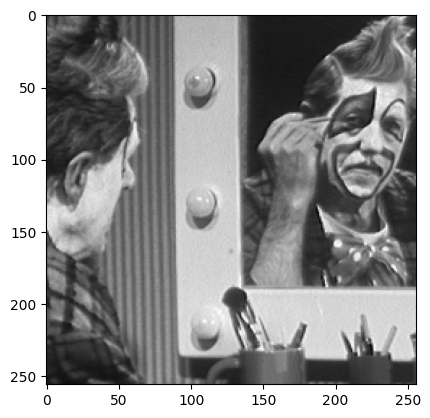

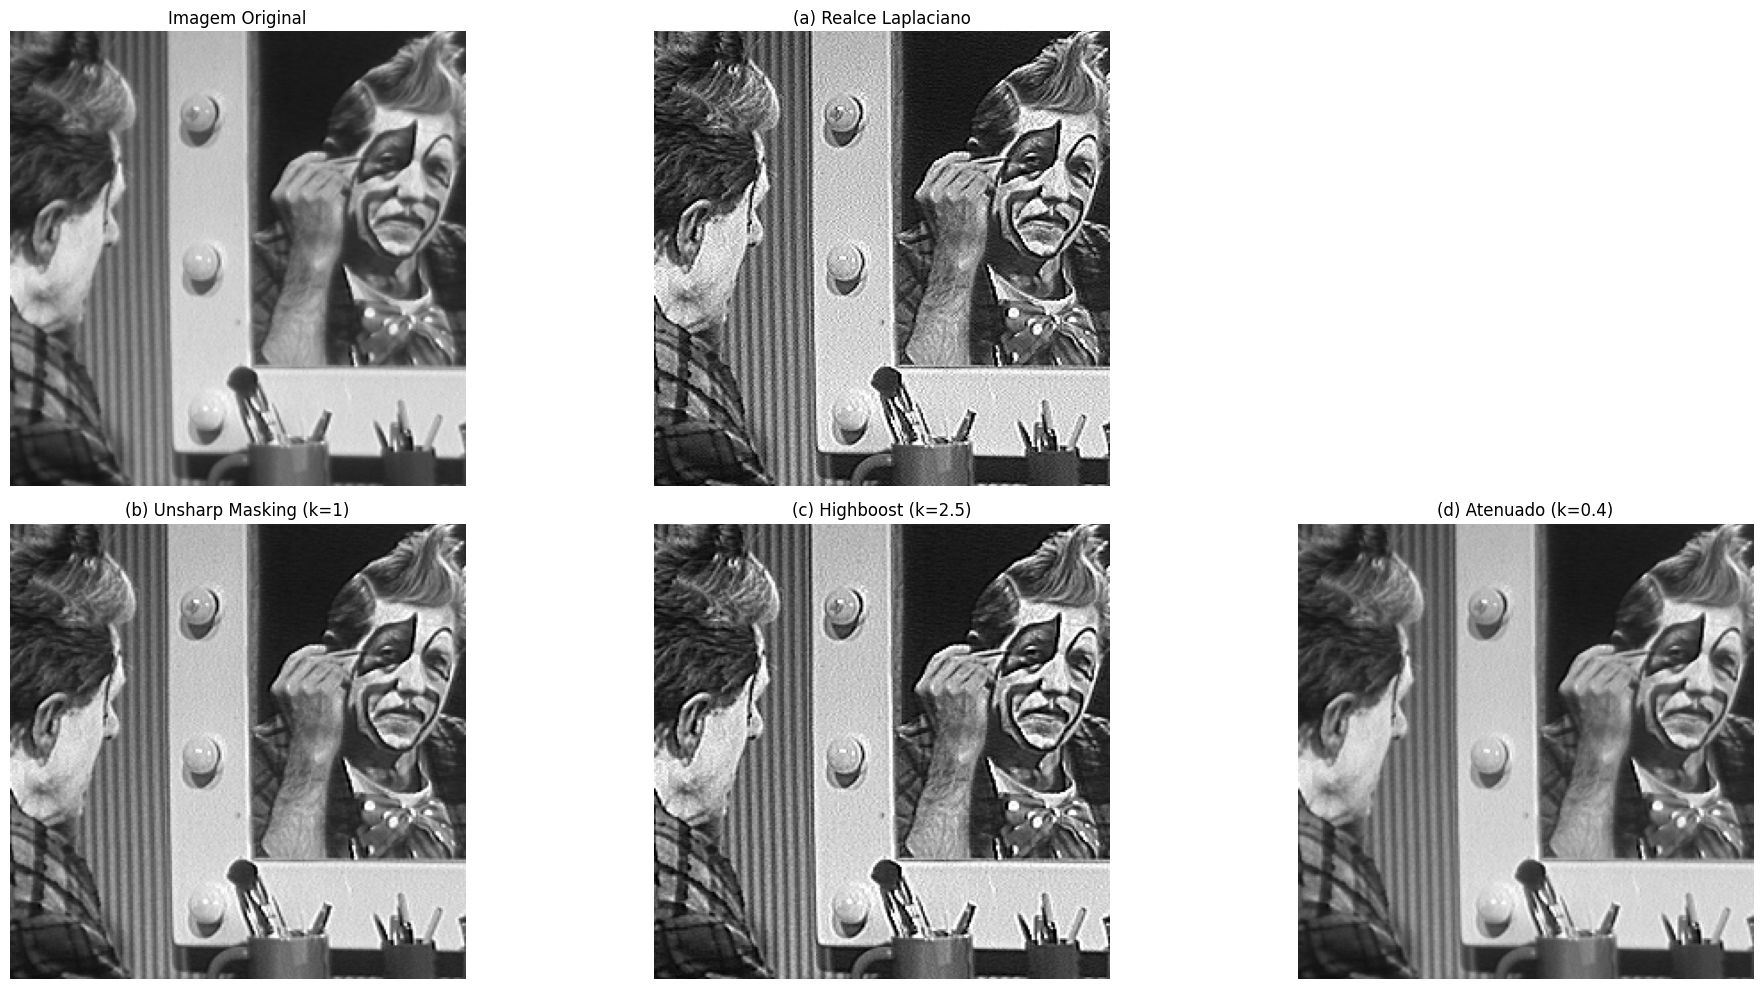

In [3]:
img1 = cv2.imread("cln1.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(img1, cmap='gray', vmin=0, vmax=255)
img_float = img1.astype(np.float64)

laplacian = cv2.Laplacian(img_float, cv2.CV_64F)

img_laplacian = img_float - laplacian

img_laplacian = np.clip(img_laplacian, 0, 255).astype(np.uint8)


img_blurred = cv2.GaussianBlur(img_float, (5, 5), 0)


mask = img_float - img_blurred


img_unsharp = img_float + (1.0 * mask)
img_unsharp = np.clip(img_unsharp, 0, 255).astype(np.uint8)


k_high = 2.5
img_highboost = img_float + (k_high * mask)
img_highboost = np.clip(img_highboost, 0, 255).astype(np.uint8)


k_low = 0.4
img_attenuated = img_float + (k_low * mask)
img_attenuated = np.clip(img_attenuated, 0, 255).astype(np.uint8)



plt.figure(figsize=(20, 10))

plt.subplot(2, 3, 1)
plt.imshow(img1, cmap='gray', vmin=0, vmax=255)
plt.title('Imagem Original')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(img_laplacian, cmap='gray', vmin=0, vmax=255)
plt.title('(a) Realce Laplaciano')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(img_unsharp, cmap='gray', vmin=0, vmax=255)
plt.title('(b) Unsharp Masking (k=1)')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(img_highboost, cmap='gray', vmin=0, vmax=255)
plt.title(f'(c) Highboost (k={k_high})')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(img_attenuated, cmap='gray', vmin=0, vmax=255)
plt.title(f'(d) Atenuado (k={k_low})')
plt.axis('off')

plt.tight_layout()
plt.show()

3) Aplique o operador Sobel imagem original abaixo e obtenha as outras imagens conforme descrição. We can see that the intensity of many pixels on the surface is as high as along the actual edges. One reason is that the output of many edge pixels is greater than the maximum pixel value and therefore they are `cut off' at 255. To avoid this overflow we scale the range image by a factor 0.25 prior to the edge detection and then normalize the output, as can be seen in (c)

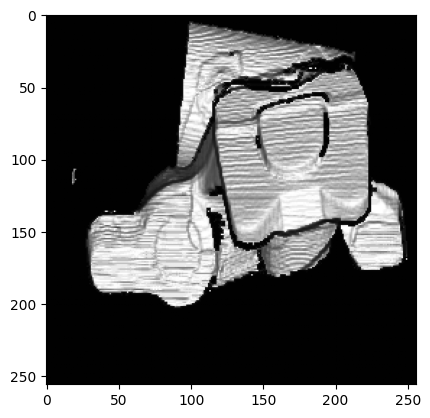

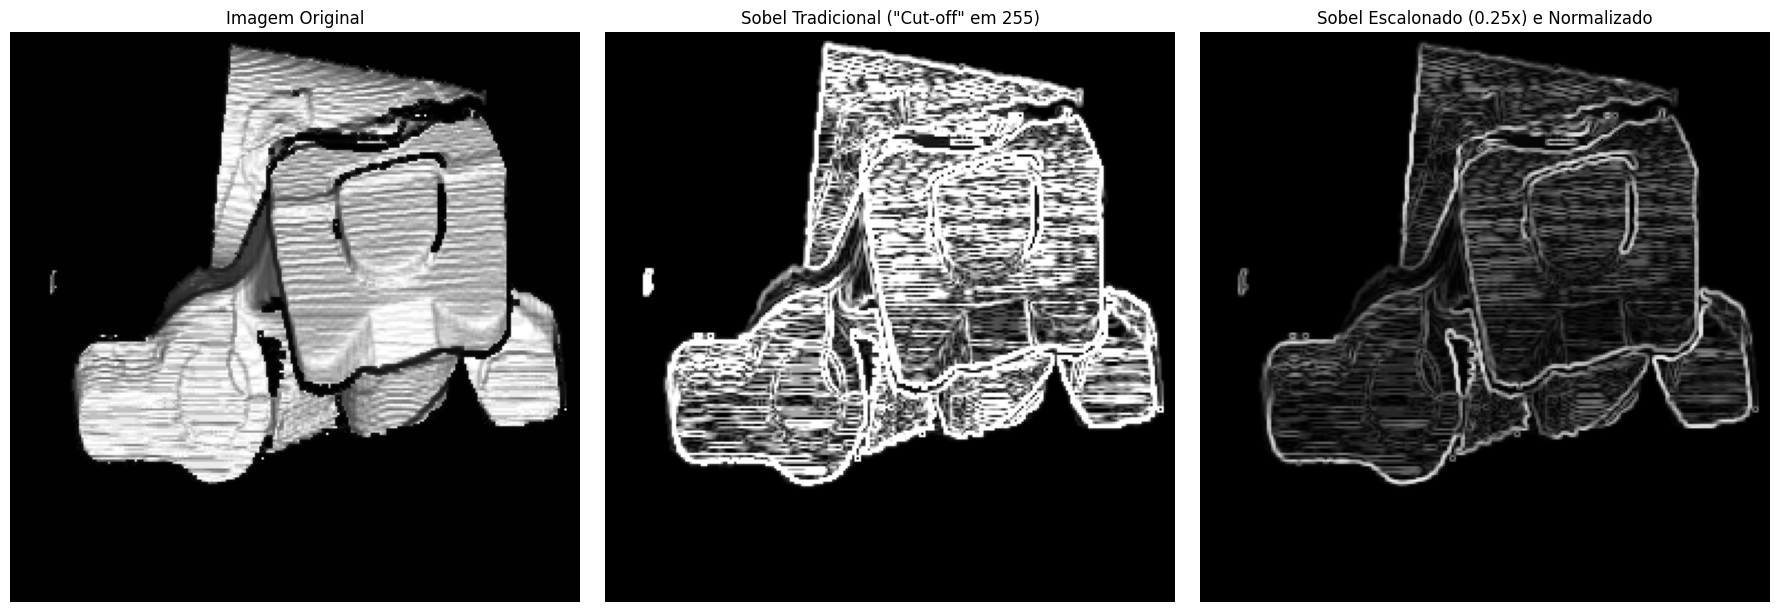

In [4]:
#code here
img1 = cv2.imread("ren1.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(img1, cmap='gray', vmin=0, vmax=255)

img_float = img1.astype(np.float64)

sobel_x = cv2.Sobel(img_float, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_float, cv2.CV_64F, 0, 1, ksize=3)

sobel_mag = cv2.magnitude(sobel_x, sobel_y)

sobel_cutoff = np.clip(sobel_mag, 0, 255).astype(np.uint8)


img_scaled = img_float * 0.25

sobel_x_scaled = cv2.Sobel(img_scaled, cv2.CV_64F, 1, 0, ksize=3)
sobel_y_scaled = cv2.Sobel(img_scaled, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag_scaled = cv2.magnitude(sobel_x_scaled, sobel_y_scaled)

sobel_normalized = cv2.normalize(
    sobel_mag_scaled, 
    None, 
    alpha=0, 
    beta=255, 
    norm_type=cv2.NORM_MINMAX, 
    dtype=cv2.CV_8U
)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(img1, cmap='gray', vmin=0, vmax=255)
plt.title('Imagem Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sobel_cutoff, cmap='gray', vmin=0, vmax=255)
plt.title('Sobel Tradicional ("Cut-off" em 255)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(sobel_normalized, cmap='gray', vmin=0, vmax=255)
plt.title('Sobel Escalonado (0.25x) e Normalizado')
plt.axis('off')

plt.tight_layout()
plt.show()

4) Aplique o operador Sobel imagem original abaixo e obtenha a imagem binária após a limiarização utilizando o valor 150

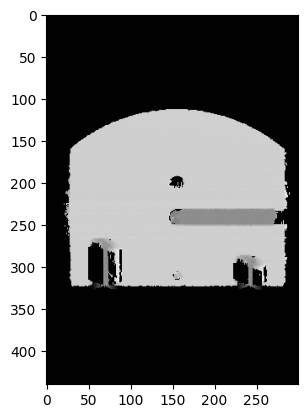

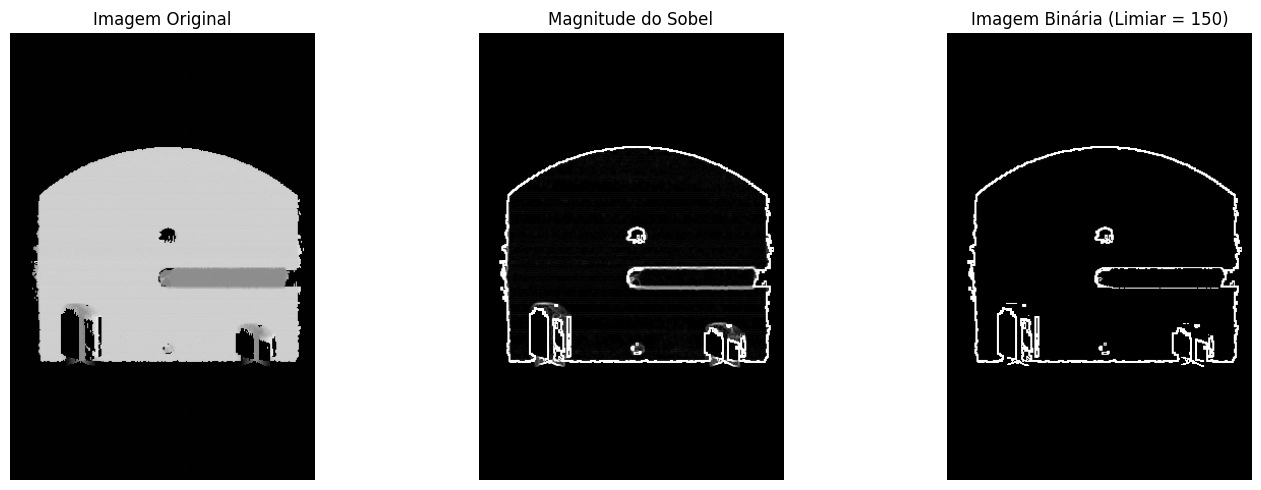

In [5]:
img1 = cv2.imread("ufo2.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(img1, cmap='gray', vmin=0, vmax=255)
sobel_x = cv2.Sobel(img1, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img1, cv2.CV_64F, 0, 1, ksize=3)

sobel_mag = cv2.magnitude(sobel_x, sobel_y)

sobel_8u = np.clip(sobel_mag, 0, 255).astype(np.uint8)


limiar = 150
_, img_binary = cv2.threshold(sobel_8u, limiar, 255, cv2.THRESH_BINARY)


plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img1, cmap='gray', vmin=0, vmax=255)
plt.title('Imagem Original')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(sobel_8u, cmap='gray', vmin=0, vmax=255)
plt.title('Magnitude do Sobel')
plt.axis('off')


plt.subplot(1, 3, 3)
plt.imshow(img_binary, cmap='gray', vmin=0, vmax=255)
plt.title(f'Imagem Binária (Limiar = {limiar})')
plt.axis('off')

plt.tight_layout()
plt.show()

5) Aplique o operador Sobel imagem original abaixo e obtenha a imagem binária após a limiarização utilizando o valor 150

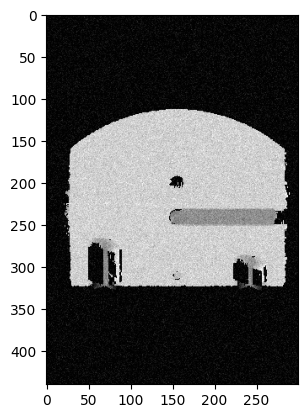

In [ ]:
img1 = cv2.imread("ufo2noi2.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(img1, cmap='gray', vmin=0, vmax=255)